In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.style.use("ggplot")

# Resampling

In the previous notebook, we saw the purpose and applications of a variety of sampling methods. Although they are useful, they are often impractical, since we cannot sample repeatedly from the population we are interested in. That's where resampling methods come into play.

The purpose of resampling methods is to get more out of a single sample. Let's see how.

## Jackknife

Jackknife is one of the first resampling methods we will cover. It was introduced by Maurice Quenouille in 1949 and later expanded by John Tukey in the 1950s. The method leaves out each data point once and collects the resulting sample statistics. The variability of these statistics is then used to report the error margin of the original estimate.

### Formulas

If we have a sample of size $n$, the $i$-th jackknife estimate $\hat{\theta}_{(i)}$ is calculated by removing the $i$-th observation:

$\hat{\theta}_{(i)} = f(x_1, x_2, ..., x_{i-1}, x_{i+1}, ..., x_n)$

Then the mean of the jackknife estimates is computed by:

$\bar{\theta}_{jack} = \frac{1}{n} \sum_{i=1}^{n} \hat{\theta}_{(i)}$

The bias-corrected jackknife estimate is given by:

$\hat{\theta}_{jack} = n\hat{\theta} - (n-1)\bar{\theta}_{jack}$

where $\hat{\theta}$ is the estimate from the original full sample.

Finally, the jackknife standard error is given by:

$SE_{jack} = \sqrt{\frac{n-1}{n} \sum_{i=1}^{n} (\hat{\theta}_{(i)} - \bar{\theta}_{jack})^2}$



**Example**

$\text{population} \sim \text{Exp}(\text{scale}=5) \quad (n = 1000)$

$\text{sample} \sim \text{population} \quad (n = 30)$

In [2]:
np.random.seed(42)
population = np.random.exponential(scale=5, size=1000)
sample = np.random.choice(population, size=30)

jackknife_means = []
for i in range(len(sample)):
    resample = np.delete(sample, i)
    jackknife_means.append(resample.mean())

jackknife_means = np.array(jackknife_means)

n = len(sample)
theta_hat = sample.mean()
theta_bar_jack = jackknife_means.mean()

theta_jack = n * theta_hat - (n - 1) * theta_bar_jack
variance_jk = ((n - 1) / n) * np.sum((jackknife_means - theta_bar_jack)**2)
se_jk = np.sqrt(variance_jk)

print(f"Original Estimate: {theta_hat:.4f}")
print(f"Mean of Leave-One-Out Estimates: {theta_bar_jack:.4f}")
print(f"Bias-Corrected Jackknife Estimate: {theta_jack:.4f}")
print(f"Jackknife Standard Error: {se_jk:.4f}")

Original Estimate: 5.3180
Mean of Leave-One-Out Estimates: 5.3180
Bias-Corrected Jackknife Estimate: 5.3180
Jackknife Standard Error: 0.7783


Note that for the mean estimate, since $\bar{\theta}_{jack} = \hat{\theta}$, substituting into the bias-corrected formula gives:

$\hat{\theta}_{jack} = n\hat{\theta} - (n-1)\bar{\theta}_{jack} = n\hat{\theta} - (n-1)\hat{\theta} = \hat{\theta}$

So $\hat{\theta}_{jack} = \bar{\theta}_{jack} = \hat{\theta}$ (The bias corrected and leave one out estimates are exactly the same.)


Although it is useful, Jackknife has a couple of limitations:
* Jackknife does not work well for all sample statistics. For example, leaving one data point out in each round does not affect the sample median much, which makes its variability estimate unreliable.
* The number of Jackknife estimates is predetermined by the original sample size. Edge statistics like the 97.5th percentile require more estimates, since they are more sensitive to changes.
* It is deterministic. The number of simulations we can run is therefore limited. This can be a problem when we use resampling methods for model evaluation.


## Bootstrap

Bootstrap resampling was invented by Bradley Efron in 1979. It overcomes many of the limitations jackknife has and is still used frequently by statisticians for many applications.

In bootstrapping, we randomly sample $n$ data points from the original sample of size $n$, with replacement. It is extremely useful for measuring the variability of a point estimate, because when we run a sufficient number of bootstrap simulations, the Central Limit Theorem (CLT) kicks in and we obtain a normal distribution for the statistic. Moreover, since resampling is random rather than deterministic, we can simulate as many different resamples as we want.

**Example**

$\text{sample} \sim \text{Exp}(\text{scale}=1) \quad (n = 1000)$

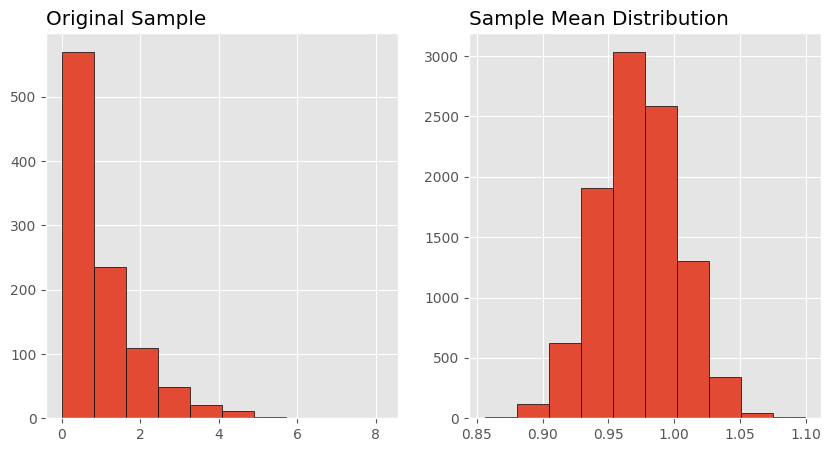

In [3]:
sample = stats.expon.rvs(size = 1000,random_state = 42)
boots = stats.bootstrap((sample,),statistic = np.mean,random_state = 42)
fig,ax = plt.subplots(1,2,figsize = (10,5))
ax[0].hist(sample,edgecolor = "black")
ax[0].set_title("Original Sample",loc = 'left')
ax[1].hist(boots.bootstrap_distribution, edgecolor = "black")
ax[1].set_title("Sample Mean Distribution",loc = 'left')
fig.show()

There are a couple of ways to obtain a confidence interval from the bootstrap distribution.

The first one uses the mean and standard deviation. As you may remember from your statistics class, 95% of the area under a normal distribution lies between approximately two standard deviations away from the mean:

$CI_{boot} = \mu_{boot} \pm z^{\star} \times \sigma_{boot}$

In [4]:
dist = boots.bootstrap_distribution.copy()
mu = dist.mean()
sigma = dist.std()
ci95 = (mu-1.96*sigma,mu+1.96*sigma)
ci95

(np.float64(0.9125624592020178), np.float64(1.0325836036024476))

We can also use percentiles for the same purpose.


In [5]:
ci95_percentile = (np.percentile(dist,2.5),np.percentile(dist,97.5))
ci95_percentile

(np.float64(0.9119063572938082), np.float64(1.0327692341229757))

We can also use a *bias-corrected and accelerated (BCa) bootstrap confidence interval*, which is supported by the bootstrap function:

In [6]:
ci_bca = boots.confidence_interval
ci_bca

ConfidenceInterval(low=np.float64(0.9140462104451859), high=np.float64(1.0343993438651762))

### How Many Bootstraps to Use?

A good rule of thumb for deciding how many bootstrap samples to use is to set B = 10,000. This often works great thanks to the powerful computers we have today. However, in some cases, resampling 10,000 times can become computationally expensive (for example, when we need to fit a complex model to each bootstrap sample). In these cases, we can plot how our statistic of interest changes as B increases, and stop once the estimate has stabilized. As a general rule, the more sensitive a statistic is, such as extreme quantiles (e.g., the 99.7th percentile), the more bootstrap samples are needed for the estimate to converge.

In [7]:
np.random.seed(42)
sample = np.random.randint(low = 10, high = 300, size = 100)

means = []
percentile_two_point_five = []
percentile_ninety_seven_point_five = []
bootstrap_candidates = np.linspace(start = 20, stop = 200, num = 10)

for bootstrap_candidate in bootstrap_candidates:
    boots = stats.bootstrap((sample,),
                             statistic = np.mean,
                             random_state = 42,
                             n_resamples = int(bootstrap_candidate))
    means.append(np.mean(boots.bootstrap_distribution))
    percentile_two_point_five.append(np.percentile(boots.bootstrap_distribution,2.5))
    percentile_ninety_seven_point_five.append(np.percentile(boots.bootstrap_distribution,97.5))

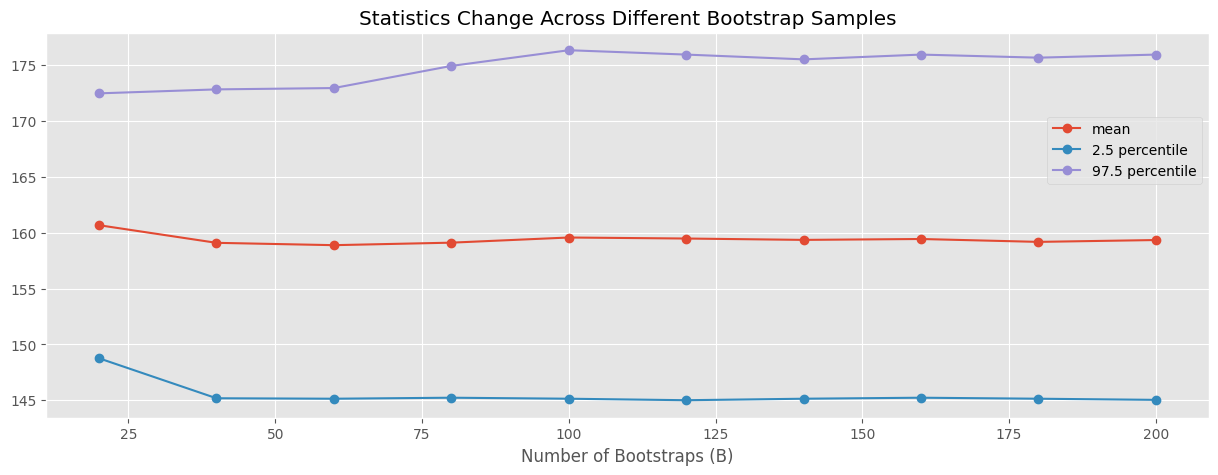

In [8]:
plt.figure(figsize = (15,5))
plt.plot(bootstrap_candidates, means, label="mean",marker = "o")
plt.plot(bootstrap_candidates, percentile_two_point_five, label="2.5 percentile",marker = "o")
plt.plot(bootstrap_candidates, percentile_ninety_seven_point_five, label="97.5 percentile",marker = "o")
plt.xlabel("Number of Bootstraps (B)")
plt.title("Statistics Change Across Different Bootstrap Samples")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.show()